In [ ]:
from PySide6.QtWidgets import QApplication, QWidget, QPushButton, QLabel, QVBoxLayout, QHBoxLayout, QFileDialog, QComboBox, QListWidget, QColorDialog,\
    QInputDialog, QLineEdit, QListWidgetItem
from PySide6.QtCore import Qt
from PySide6.QtGui import QColor  # Asegúrate de importar esto
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
import sys
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import contextily as ctx
fiona.drvsupport.supported_drivers['kml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['KML'] = 'rw' # enable KML support which is disabled by default

class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de la leyenda (Inicialmente deshabilitado)
        self.legend_button = QPushButton("📜 Crear Leyenda", self)
        self.legend_button.setEnabled(False)  # Deshabilitado hasta seleccionar un segmento
        self.legend_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.open_legend_creator)
        self.layout.addWidget(self.legend_button)

      
        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
        
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
            
            
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        gdf_segment["length_m"] = gdf_segment["geometry"].length
        self.length_m = gdf_segment["length_m"].iloc[0]
        
        gdf_segment.plot(ax=self.ax, color="black", lw=4)
        gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    
    def open_legend_creator(self):
        """ Abre la ventana de creación de leyenda y pasa la referencia de la ventana principal """
        self.legend_window = LegendCreator(self.selected_segment, self.length_m, parent=self)
        self.legend_window.show()

    def receive_legend_data(self, legend_data):
        """ Recibe los datos de la leyenda desde la ventana LegendCreator y los guarda """
        self.legend_data_global = legend_data
        print("📜 Leyenda guardada globalmente:", self.legend_data_global)  # Verificación en consola

    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()



class LegendCreator(QWidget):
    def __init__(self, segment_name, length_m, parent=None):
        super().__init__(parent, Qt.Window)  # Ensure it is a separate window
        self.parent_window = parent
        self.segment_name = segment_name
        self.length_m = length_m
        self.legend_data = {}  # Diccionario para almacenar los valores de la leyenda
        self.initUI()
        


    def initUI(self):
        """ Inicializa la ventana de creación de leyenda """
        self.setWindowTitle("Crear Leyenda")
        self.setGeometry(200, 200, 500, 400)
        self.setStyleSheet("background-color: #f4f4f4; font-family: Arial; font-size: 14px;")

        layout = QVBoxLayout()

        # Etiqueta con el tramo seleccionado
        self.label = QLabel(f"📌 Segmento: {self.segment_name}\n📏 Longitud: {self.length_m/1000:.2f} km", self)
        self.label.setStyleSheet("font-weight: bold; background-color: white; padding: 10px; border-radius: 5px;")
        layout.addWidget(self.label)

        # Etiqueta para indicar qué hacer
        self.legend_label = QLabel("Añadir nueva entrada a la leyenda:", self)
        self.legend_label.setStyleSheet("font-weight: bold; padding: 5px;")
        layout.addWidget(self.legend_label)

        # Layout horizontal para los inputs
        input_layout = QHBoxLayout()

        # Input para el texto
        self.text_input = QLineEdit(self)
        self.text_input.setPlaceholderText("Texto de la leyenda")
        self.text_input.setStyleSheet("padding: 5px; border-radius: 5px; background-color: white;")
        input_layout.addWidget(self.text_input)

        # Botón de selección de color
        self.color_button = QPushButton("🎨 Color", self)
        self.color_button.setStyleSheet("background-color: #D3D3D3; padding: 5px; border-radius: 5px;")
        self.color_button.clicked.connect(self.choose_color)
        input_layout.addWidget(self.color_button)

        # Agregar el layout horizontal a la ventana
        layout.addLayout(input_layout)

        # Botón para añadir la entrada
        self.add_button = QPushButton("➕ Añadir", self)
        self.add_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.add_button.clicked.connect(self.add_legend_entry)
        layout.addWidget(self.add_button)

        # Lista para mostrar la leyenda creada
        self.legend_list = QListWidget(self)
        self.legend_list.itemClicked.connect(self.enable_edit_delete_buttons)
        self.legend_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        layout.addWidget(self.legend_list)

        # Layout horizontal para los botones de editar y eliminar
        self.edit_delete_layout = QHBoxLayout()

        # Botón para editar
        self.edit_button = QPushButton("✏ Editar", self)
        self.edit_button.setStyleSheet("""
            QPushButton {
                background-color: #B0B0B0;  /* Gris apagado */
                color: white;
                padding: 8px;
                border-radius: 5px;
            }
            QPushButton:enabled {
                background-color: #FFA500; /* Naranja cuando esté activado */
            }
        """)
        self.edit_button.setEnabled(False)
        self.edit_button.clicked.connect(self.edit_selected_item)
        self.edit_delete_layout.addWidget(self.edit_button)

        # Botón para eliminar
        self.delete_button = QPushButton("🗑 Eliminar", self)
        self.delete_button.setStyleSheet("""
            QPushButton {
                background-color: #B0B0B0;
                color: white;
                padding: 8px;
                border-radius: 5px;
            }
            QPushButton:enabled {
                background-color: #DC3545; /* Rojo cuando esté activado */
            }
        """)
        self.delete_button.setEnabled(False)
        self.delete_button.clicked.connect(self.delete_selected_item)
        self.edit_delete_layout.addWidget(self.delete_button)

        layout.addLayout(self.edit_delete_layout)


        # Botón para cerrar
        self.close_button = QPushButton("🔙 Volver", self)
        self.close_button.setStyleSheet("background-color: #9370DB; color: #000000; padding: 8px; border-radius: 5px;")
        self.close_button.clicked.connect(self.close)
        layout.addWidget(self.close_button)

        self.setLayout(layout)
        

    def choose_color(self):
        """Abre un diálogo para seleccionar un color y cambia el fondo del botón"""
        color = QColorDialog.getColor()
        if color.isValid():
            self.selected_color = color.name()
            self.color_button.setStyleSheet(f"background-color: {self.selected_color}; color: white;")
            
    def add_legend_entry(self):
        """Añade una nueva entrada al diccionario de la leyenda y la muestra en la lista"""
        text = self.text_input.text()
        
        if not text:
            return  # No añadir si el texto está vacío

        color = getattr(self, "selected_color", "#000000")  # Negro por defecto

        self.legend_data[text] = color  # Guardar en el diccionario

        # Añadir a la lista visual con color de fondo
        item = QListWidgetItem(text)
        item.setBackground(QColor(color))  # Convertir a QColor antes de usar
        item.setForeground(QColor("#FFFFFF"))  # Texto en blanco para contraste
        self.legend_list.addItem(item)

        # Limpiar inputs
        self.text_input.clear()
        self.selected_color = None
        self.color_button.setStyleSheet("background-color: #D3D3D3;")

    def enable_edit_delete_buttons(self):
        """Habilita los botones de editar y eliminar cuando un elemento está seleccionado"""
        self.edit_button.setEnabled(True)
        self.delete_button.setEnabled(True)
        
    def delete_selected_item(self):
        """Elimina el elemento seleccionado de la lista y del diccionario"""
        selected_item = self.legend_list.currentItem()
        if selected_item:
            item_text = selected_item.text().split(":")[0].strip()  # Extraer la clave del diccionario
            del self.legend_data[item_text]  # Eliminar del diccionario
            self.legend_list.takeItem(self.legend_list.row(selected_item))  # Eliminar de la UI
            
            # Desactivar los botones tras la eliminación
            self.edit_button.setEnabled(False)
            self.delete_button.setEnabled(False)
            
    def edit_selected_item(self):
        """Permite editar el color y el texto del elemento seleccionado"""
        selected_item = self.legend_list.currentItem()
        if not selected_item:
            return

        old_key = selected_item.text().strip()  # Extraer clave actual
        old_value = self.legend_data[old_key]  # Obtener el color actual

        # Solicitar nuevo texto
        new_text, ok = QInputDialog.getText(self, "Editar Texto", "Nuevo significado:", text=old_key)
        if ok and new_text.strip():
            # Seleccionar nuevo color
            color = QColorDialog.getColor(QColor(old_value), self, "Seleccionar nuevo color")
            if color.isValid():
                new_color_hex = color.name()

                # Actualizar el diccionario correctamente
                if new_text != old_key:  # Si el nombre cambió, eliminar la clave antigua
                    del self.legend_data[old_key]

                self.legend_data[new_text] = new_color_hex  # Guardar con la nueva clave

                # Actualizar visualmente
                selected_item.setText(new_text)
                selected_item.setBackground(QColor(new_color_hex))

    def closeEvent(self, event):
        """ Pasa los datos de la leyenda a la ventana principal antes de cerrar """
        if self.parent():
            self.parent().receive_legend_data(self.legend_data)
        event.accept()
        

    
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()

📜 Leyenda guardada globalmente: {'ba': '#5555ff', 'as': '#77ffd6'}


## Primera Pestaña del Código OK

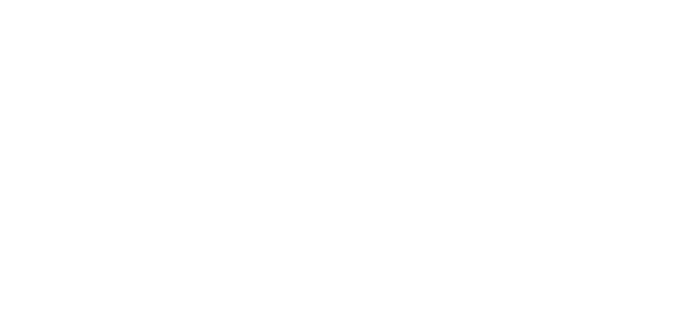

In [11]:
from PySide6.QtWidgets import QApplication, QWidget, QPushButton, QLabel, QVBoxLayout, QHBoxLayout, QFileDialog, QComboBox, QListWidget
from PySide6.QtCore import Qt
from matplotlib.backends.backend_qtagg import FigureCanvasQTAgg as FigureCanvas
import sys
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import contextily as ctx
fiona.drvsupport.supported_drivers['kml'] = 'rw' # enable KML support which is disabled by default
fiona.drvsupport.supported_drivers['KML'] = 'rw' # enable KML support which is disabled by default

class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de leyenda
        self.legend_button = QPushButton("🖍️ Pasar a Creación de Leyenda", self)
        self.legend_button.setEnabled(False)
        self.legend_button.setStyleSheet("background-color: gray; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.go_to_legend_creation)
        self.layout.addWidget(self.legend_button)

      
        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
            
            
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        gdf_segment["length_m"] = gdf_segment["geometry"].length
        self.length_m = gdf_segment["length_m"].iloc[0]
        
        gdf_segment.plot(ax=self.ax, color="black", lw=4)
        gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    
    def go_to_legend_creation(self):
        """ Función para cambiar a la pantalla de creación de leyenda """
        print(f"Pasando a la creación de leyenda para: {self.selected_segment}")
        # Aquí podrías abrir una nueva ventana o cambiar el contenido del GUI
    
    
    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()
        
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()

AttributeError: 'FileSelector' object has no attribute 'open_legend_creator'

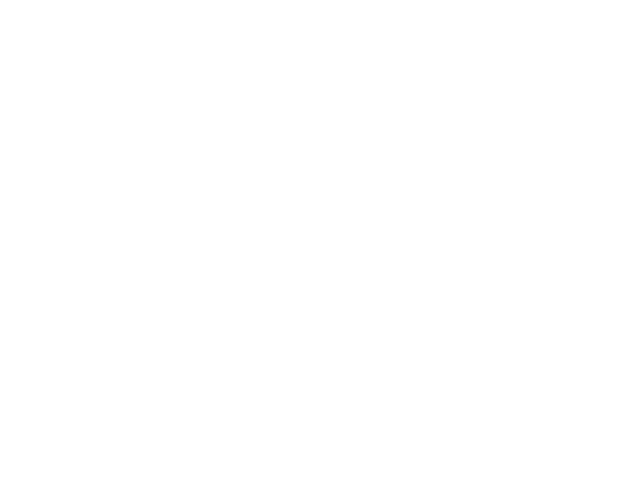

In [12]:


class FileSelector(QWidget):
    def __init__(self):
        super().__init__()
        self.file_path = ""  # Variable para almacenar la ruta del archivo seleccionado
        self.selected_segment = None  # Segmento seleccionado
        self.length_m = 0  # Longitud del segmento seleccionado
        self.initUI()

    def initUI(self):
        """ Inicializa la interfaz gráfica """
        self.setWindowTitle("Seleccionar Archivo KML")  # Título de la ventana
        self.setGeometry(100, 100, 700, 700)  # Ajustamos el tamaño de la ventana
        self.setStyleSheet("""
            background-color: #f4f4f4;
            font-family: Arial;
            font-size: 14px;
        """)
        
        # Layout principal
        self.layout = QVBoxLayout()
        
        # Etiqueta para mostrar el archivo seleccionado
        self.label = QLabel("Selecciona un archivo .kml", self)
        self.layout.addWidget(self.label)
        
        # Botón para seleccionar archivo
        self.button = QPushButton("📂 Abrir Archivo", self)
        self.button.setStyleSheet("background-color: #0078D7; color: white; padding: 8px; border-radius: 5px;")
        self.button.clicked.connect(self.open_file)
        self.layout.addWidget(self.button)
        
        # Layout horizontal para el ComboBox y el botón "Dibujar"
        self.layer_layout = QHBoxLayout()
        
        # ComboBox para capas disponibles
        self.layer_combo = QComboBox(self)
        self.layer_combo.setEnabled(False)
        self.layer_combo.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.layer_layout.addWidget(self.layer_combo)
        
        # Botón para dibujar la capa seleccionada
        self.draw_button = QPushButton("🎨 Dibujar", self)
        self.draw_button.setEnabled(False)
        self.draw_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.draw_button.clicked.connect(self.plot_layer)
        self.layer_layout.addWidget(self.draw_button)
        
        self.layout.addLayout(self.layer_layout)
        
        # Lienzo de Matplotlib para mostrar gráficos (aumentado en tamaño)
        self.figure, self.ax = plt.subplots(figsize=(8, 6))
        self.ax.axis("off")  # Ocultar ejes desde el inicio
        self.canvas = FigureCanvas(self.figure)
        self.layout.addWidget(self.canvas, stretch=3)
        
        # Texto aclaratorio para la lista interactiva
        self.list_label = QLabel("Selecciona un tramo:", self)
        self.list_label.setStyleSheet("font-weight: bold; padding: 5px;")
        self.layout.addWidget(self.list_label)
    
        # Lista interactiva para mostrar nombres de los segmentos
        self.names_list = QListWidget(self)
        self.names_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        self.names_list.itemEntered.connect(self.highlight_segment)
        self.names_list.itemClicked.connect(self.select_segment)
        self.layout.addWidget(self.names_list, stretch=1)
        
        # Etiqueta para mostrar el segmento seleccionado y su longitud
        self.segment_label = QLabel("Segmento seleccionado: Ninguno", self)
        self.segment_label.setStyleSheet("font-weight: bold; background-color: white; padding: 5px; border-radius: 5px;")
        self.layout.addWidget(self.segment_label)

        # Botón para pasar a la creación de la leyenda (Inicialmente deshabilitado)
        self.legend_button = QPushButton("📜 Crear Leyenda", self)
        self.legend_button.setEnabled(False)  # Deshabilitado hasta seleccionar un segmento
        self.legend_button.setStyleSheet("background-color: grey; color: white; padding: 8px; border-radius: 5px;")
        self.legend_button.clicked.connect(self.open_legend_creator)
        self.layout.addWidget(self.legend_button)

      
        # Botón para salir del programa
        self.exit_button = QPushButton("❌ Salir", self)
        self.exit_button.setStyleSheet("background-color: #DC3545; color: white; padding: 8px; border-radius: 5px;")
        self.exit_button.clicked.connect(self.close_application)
        self.layout.addWidget(self.exit_button)
        
        self.setLayout(self.layout)
    def open_file(self):
        """ Abre un cuadro de diálogo para seleccionar un archivo KML y carga las capas disponibles """
        file_dialog = QFileDialog()
        self.file_path, _ = file_dialog.getOpenFileName(self, "Seleccionar Archivo KML", "", "Archivos KML (*.kml)")
        
        if self.file_path:
            file_name = os.path.basename(self.file_path)  # Extraer solo el nombre del archivo
            self.label.setText(f"Archivo seleccionado: {file_name}")
            self.load_layers()

    def load_layers(self):
        """ Carga y lista las capas disponibles en el archivo KML seleccionado """
        try:
            layers = fiona.listlayers(self.file_path)
            self.layer_combo.clear()
            self.layer_combo.addItems(layers)
            self.layer_combo.setEnabled(True)
            self.draw_button.setEnabled(True)
        except Exception as e:
            self.label.setText(f"Error cargando capas: {str(e)}")
            
            
    def plot_layer(self):
        """ Plotea la capa seleccionada en la GUI con mapa de fondo y muestra los nombres """
        selected_layer = self.layer_combo.currentText()
        
        if not selected_layer:
            self.label.setText("Selecciona una capa antes de dibujar")
            return
        
        try:
            self.gdf = gpd.read_file(self.file_path, driver="KML", layer=selected_layer)
            self.gdf = self.gdf.to_crs(epsg=3857)
            
            self.ax.clear()
            self.ax.axis("off")
            self.gdf.plot(ax=self.ax, color="black", lw=2)
            ctx.add_basemap(self.ax, crs=self.gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
            
            # Añadir nombres en el mapa
            for idx, row in self.gdf.iterrows():
                x, y = row.geometry.centroid.x, row.geometry.centroid.y
                self.ax.text(x, y, row["Name"], fontsize=9, ha='center', color='blue', 
                             bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.3'))
            
            self.canvas.draw()
            
            self.names_list.clear()
            for name in self.gdf["Name"]:
                self.names_list.addItem(name)
            
        except Exception as e:
            self.label.setText(f"Error al dibujar: {str(e)}")
    
    def highlight_segment(self, item):
        """ Plotea únicamente el segmento seleccionado y elimina los ejes """
        self.ax.clear()
        self.ax.axis("off")
        self.selected_segment = item.text()
        
        gdf_segment = self.gdf[self.gdf["Name"] == self.selected_segment].to_crs(epsg=3099)
        gdf_segment["length_m"] = gdf_segment["geometry"].length
        self.length_m = gdf_segment["length_m"].iloc[0]
        
        gdf_segment.plot(ax=self.ax, color="black", lw=4)
        gdf_segment.plot(ax=self.ax, color="white", lw=.5)
        
        # Añadir nombre del segmento como título de la gráfica
        self.ax.set_title(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km", fontsize=12)
        
        ctx.add_basemap(self.ax, crs=gdf_segment.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)
        
        self.canvas.draw()
    
    def select_segment(self, item):
        """ Actualiza la etiqueta con el segmento seleccionado y su longitud """
        self.highlight_segment(item)
        self.segment_label.setText(f"Segmento seleccionado: {self.selected_segment} | Longitud: {self.length_m/1000:.2f} km")
        # Habilitar el botón de leyenda y cambiar su color
        self.legend_button.setEnabled(True)
        self.legend_button.setStyleSheet("background-color: #0078D7; color: white;")
    
    
    def go_to_legend_creation(self):
        """ Función para cambiar a la pantalla de creación de leyenda """
        print(f"Pasando a la creación de leyenda para: {self.selected_segment}")
        # Aquí podrías abrir una nueva ventana o cambiar el contenido del GUI
    
    
    def close_application(self):
        """ Cierra la aplicación correctamente """
        QApplication.quit()
        
        
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()

## Creación de la leyenda

TypeError: LegendCreator.__init__() got an unexpected keyword argument 'parent'

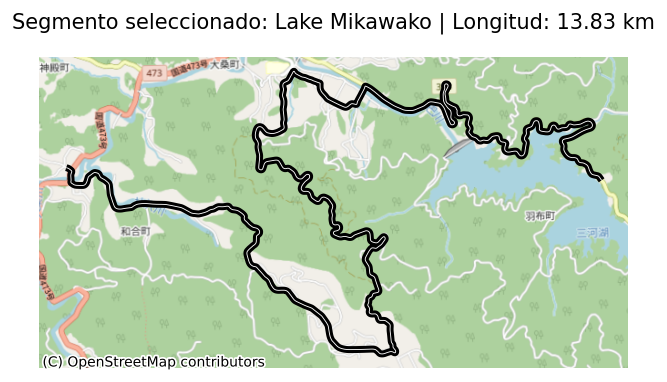

In [17]:
class LegendCreator(QWidget):
    def __init__(self, segment_name, length_m):
        super().__init__()
        self.segment_name = segment_name
        self.length_m = length_m
        self.legend_data = {}  # Diccionario para almacenar los valores de la leyenda
        self.initUI()
        


    def initUI(self):
        """ Inicializa la ventana de creación de leyenda """
        self.setWindowTitle("Crear Leyenda")
        self.setGeometry(200, 200, 500, 400)
        self.setStyleSheet("background-color: #f4f4f4; font-family: Arial; font-size: 14px;")

        layout = QVBoxLayout()

        # Etiqueta con el tramo seleccionado
        self.label = QLabel(f"📌 Segmento: {self.segment_name}\n📏 Longitud: {self.length_m/1000:.2f} km", self)
        self.label.setStyleSheet("font-weight: bold; background-color: white; padding: 10px; border-radius: 5px;")
        layout.addWidget(self.label)

        # Etiqueta para indicar qué hacer
        self.legend_label = QLabel("Añadir nueva entrada a la leyenda:", self)
        self.legend_label.setStyleSheet("font-weight: bold; padding: 5px;")
        layout.addWidget(self.legend_label)

        # Layout horizontal para los inputs
        input_layout = QHBoxLayout()

        # Input para el texto
        self.text_input = QLineEdit(self)
        self.text_input.setPlaceholderText("Texto de la leyenda")
        self.text_input.setStyleSheet("padding: 5px; border-radius: 5px; background-color: white;")
        input_layout.addWidget(self.text_input)

        # Botón de selección de color
        self.color_button = QPushButton("🎨 Color", self)
        self.color_button.setStyleSheet("background-color: #D3D3D3; padding: 5px; border-radius: 5px;")
        self.color_button.clicked.connect(self.choose_color)
        input_layout.addWidget(self.color_button)

        # Agregar el layout horizontal a la ventana
        layout.addLayout(input_layout)

        # Botón para añadir la entrada
        self.add_button = QPushButton("➕ Añadir", self)
        self.add_button.setStyleSheet("background-color: #28A745; color: white; padding: 8px; border-radius: 5px;")
        self.add_button.clicked.connect(self.add_legend_entry)
        layout.addWidget(self.add_button)

        # Lista para mostrar la leyenda creada
        self.legend_list = QListWidget(self)
        self.legend_list.itemClicked.connect(self.enable_edit_delete_buttons)
        self.legend_list.setStyleSheet("background-color: white; padding: 5px; border-radius: 5px;")
        layout.addWidget(self.legend_list)

        # Layout horizontal para los botones de editar y eliminar
        self.edit_delete_layout = QHBoxLayout()

        # Botón para editar
        self.edit_button = QPushButton("✏ Editar", self)
        self.edit_button.setStyleSheet("""
            QPushButton {
                background-color: #B0B0B0;  /* Gris apagado */
                color: white;
                padding: 8px;
                border-radius: 5px;
            }
            QPushButton:enabled {
                background-color: #FFA500; /* Naranja cuando esté activado */
            }
        """)
        self.edit_button.setEnabled(False)
        self.edit_button.clicked.connect(self.edit_selected_item)
        self.edit_delete_layout.addWidget(self.edit_button)

        # Botón para eliminar
        self.delete_button = QPushButton("🗑 Eliminar", self)
        self.delete_button.setStyleSheet("""
            QPushButton {
                background-color: #B0B0B0;
                color: white;
                padding: 8px;
                border-radius: 5px;
            }
            QPushButton:enabled {
                background-color: #DC3545; /* Rojo cuando esté activado */
            }
        """)
        self.delete_button.setEnabled(False)
        self.delete_button.clicked.connect(self.delete_selected_item)
        self.edit_delete_layout.addWidget(self.delete_button)

        layout.addLayout(self.edit_delete_layout)


        # Botón para cerrar
        self.close_button = QPushButton("🔙 Volver", self)
        self.close_button.setStyleSheet("background-color: #9370DB; color: #000000; padding: 8px; border-radius: 5px;")
        self.close_button.clicked.connect(self.close)
        layout.addWidget(self.close_button)

        self.setLayout(layout)
        

    def choose_color(self):
        """Abre un diálogo para seleccionar un color y cambia el fondo del botón"""
        color = QColorDialog.getColor()
        if color.isValid():
            self.selected_color = color.name()
            self.color_button.setStyleSheet(f"background-color: {self.selected_color}; color: white;")
            
    def add_legend_entry(self):
        """Añade una nueva entrada al diccionario de la leyenda y la muestra en la lista"""
        text = self.text_input.text()
        
        if not text:
            return  # No añadir si el texto está vacío

        color = getattr(self, "selected_color", "#000000")  # Negro por defecto

        self.legend_data[text] = color  # Guardar en el diccionario

        # Añadir a la lista visual con color de fondo
        item = QListWidgetItem(text)
        item.setBackground(QColor(color))  # Convertir a QColor antes de usar
        item.setForeground(QColor("#FFFFFF"))  # Texto en blanco para contraste
        self.legend_list.addItem(item)

        # Limpiar inputs
        self.text_input.clear()
        self.selected_color = None
        self.color_button.setStyleSheet("background-color: #D3D3D3;")

    def enable_edit_delete_buttons(self):
        """Habilita los botones de editar y eliminar cuando un elemento está seleccionado"""
        self.edit_button.setEnabled(True)
        self.delete_button.setEnabled(True)
        
    def delete_selected_item(self):
        """Elimina el elemento seleccionado de la lista y del diccionario"""
        selected_item = self.legend_list.currentItem()
        if selected_item:
            item_text = selected_item.text().split(":")[0].strip()  # Extraer la clave del diccionario
            del self.legend_data[item_text]  # Eliminar del diccionario
            self.legend_list.takeItem(self.legend_list.row(selected_item))  # Eliminar de la UI
            
            # Desactivar los botones tras la eliminación
            self.edit_button.setEnabled(False)
            self.delete_button.setEnabled(False)
            
    def edit_selected_item(self):
        """Permite editar el color y el texto del elemento seleccionado"""
        selected_item = self.legend_list.currentItem()
        if not selected_item:
            return

        old_key = selected_item.text().strip()  # Extraer clave actual
        old_value = self.legend_data[old_key]  # Obtener el color actual

        # Solicitar nuevo texto
        new_text, ok = QInputDialog.getText(self, "Editar Texto", "Nuevo significado:", text=old_key)
        if ok and new_text.strip():
            # Seleccionar nuevo color
            color = QColorDialog.getColor(QColor(old_value), self, "Seleccionar nuevo color")
            if color.isValid():
                new_color_hex = color.name()

                # Actualizar el diccionario correctamente
                if new_text != old_key:  # Si el nombre cambió, eliminar la clave antigua
                    del self.legend_data[old_key]

                self.legend_data[new_text] = new_color_hex  # Guardar con la nueva clave

                # Actualizar visualmente
                selected_item.setText(new_text)
                selected_item.setBackground(QColor(new_color_hex))


    
if __name__ == "__main__":
    app = QApplication.instance()  # Asegura que no haya otra instancia de QApplication
    if app is None:
        app = QApplication(sys.argv)
    window = FileSelector()
    window.show()
    app.exec()